<a href="https://colab.research.google.com/github/bely092/Trabajo_evaluativo_O-G/blob/main/TP_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## TP Consigna I
1.	Usando la base de datos “Calidad_Agua.csv” realizar un modelo de regresión lineal que permita predecir la cantidad de partículas en suspensión (turbiedad) en relación a la demanda bioquímicia de oxígeno en el agua(dbo_mg_l).
 -	Graficar, evaluar sus métricas y analizar sus resultados.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

In [4]:
df_nuevo = pd.read_csv("https://raw.githubusercontent.com/bely092/Trabajo_evaluativo_O-G/refs/heads/main/Calidad_Agua.csv", delimiter=",")
df_nuevo.head()

,sitios,fecha,tem_agua,tem_aire,od,ph,dbo_mg_l,dqo_mg_l,turbiedad_ntu
0,Canal Villanueva y Río Luján,22/2/2023,26.0,24.0,6.59,7.24,2.0,30.0,29.0
1,Río Lujan y Arroyo Caraguatá,22/2/2023,26.8,25.0,5.94,6.96,2.1,30.0,24.0
2,Canal Aliviador y Río Lujan,22/2/2023,27.6,24.0,6.14,6.88,4.1,30.0,21.0
3,Río Carapachay y Arroyo Gallo Fiambre,22/2/2023,26.1,25.0,5.02,6.82,2.2,30.0,28.0
4,Río Reconquista y Río Lujan,22/2/2023,25.9,24.0,5.28,6.69,3.3,30.0,24.0


## Mirar panorama general del dataset
tipos de datos que tiene y si contiene datos nulos

In [5]:
df_nuevo.info()
#Los non-null son valores no nulos quiere decir que no tiene valores nulos
#si tiene 169 filas y dice 147 quiere decir que tiene 22 valores nulos en esa columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sitios         169 non-null    object 
 1   fecha          169 non-null    object 
 2   tem_agua       138 non-null    float64
 3   tem_aire       142 non-null    float64
 4   od             133 non-null    float64
 5   ph             125 non-null    float64
 6   dbo_mg_l       147 non-null    float64
 7   dqo_mg_l       151 non-null    float64
 8   turbiedad_ntu  151 non-null    float64
dtypes: float64(7), object(2)
memory usage: 12.0+ KB


In [6]:
#revisar cuantos valores nulos tiene cada columna
df_nuevo.isnull().sum()

,0
sitios,0
fecha,0
tem_agua,31
tem_aire,27
od,36
ph,44
dbo_mg_l,22
dqo_mg_l,18
turbiedad_ntu,18


#### Imputar valores nulos con la media

In [7]:
#imputar valores nulos con la media de la columna
#con simpleimputer de sklearn

imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
columnas_con_nulos= ["tem_agua", "tem_aire", "od", "ph", "dbo_mg_l", "dqo_mg_l", "turbiedad_ntu"]

# fit_trsform es para que aprenda de los datos y luego transforme los datos
# que aprenda de los datos significa aprende de las media de cada columna para transformar esos valores nulos
#redondear los valores imputados
df_nuevo[columnas_con_nulos] = imputer.fit_transform(df_nuevo[columnas_con_nulos])
df_nuevo[columnas_con_nulos] = round(df_nuevo[columnas_con_nulos], 2)

In [8]:
#Revisar si quedaron valores nulos
df_nuevo.isnull().sum()

,0
sitios,0
fecha,0
tem_agua,0
tem_aire,0
od,0
ph,0
dbo_mg_l,0
dqo_mg_l,0
turbiedad_ntu,0


### Explorar los datos
describe se usa para ver las columnas turbiedad_ntu y dbo_mg_l que son las que vamos a usar
con esta funcion se puede ver la media, std, min, max, 25%, 50%, 75%

In [9]:
df_nuevo.describe()[["turbiedad_ntu", "dbo_mg_l"]]

,turbiedad_ntu,dbo_mg_l
count,169.000000,169.000000
mean,35.780118,4.208994
std,38.893490,3.351242
min,2.900000,2.000000
25%,17.000000,2.000000
50%,28.000000,3.600000
75%,40.000000,4.300000
max,432.000000,24.000000


### Visualizar con Boxplot


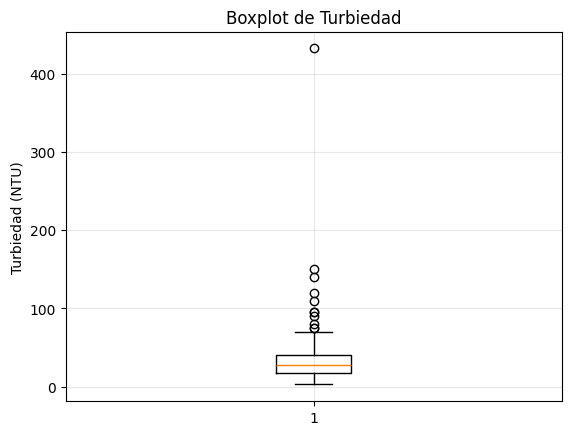

In [10]:
plt.boxplot(df_nuevo["turbiedad_ntu"])
plt.ylabel("Turbiedad (NTU)")
plt.title("Boxplot de Turbiedad")
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# metodo de Tukey para detectar outliers, se uso apuntes
#se calcula el primer cuartil y el tercer cuartil de la columna turbiedad_ntu
#este metodo se basa en la diferencia entre el tercer cuartil y el primer cuartil
Q1 = df_nuevo["turbiedad_ntu"].quantile(0.25)
Q3 = df_nuevo["turbiedad_ntu"].quantile(0.75)
IQR = Q3 - Q1

#se calculan los limites superior e inferior para determinar los outliers
#la cuenta es que si un valor es menor al limite inferior
# o mayor al limite superior se considera un outlier
limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)


Limite inferior: -17.5
Limite superior: 74.5


In [12]:
# Eliminar outliers
df_limpio = df_nuevo[(df_nuevo["turbiedad_ntu"] >= limite_inferior) &  (df_nuevo["turbiedad_ntu"] <= limite_superior)]

print(f"Datos originales: {len(df_nuevo)}")

#muestra como quedaria el dataset sin outliers
print(f"Datos sin outliers: {len(df_limpio)}")

Datos originales: 169
Datos sin outliers: 158


## Se uso df con Outlier para ver los resultados
Se opto por usar df_nuevo
- X: dbo (demanda bioquimica de oxigeno)	Variable que PREDICE
- y: Turbiedad (particulas en suspension) Variable a PREDECIR

In [13]:
#seleccionar la variable observada y variable respuesta
# variable observada es la que queremos predecir, en este caso turbiedad_ntu
x = pd.DataFrame(df_nuevo, columns=['dbo_mg_l'])
y = pd.DataFrame(df_nuevo, columns=['turbiedad_ntu'])


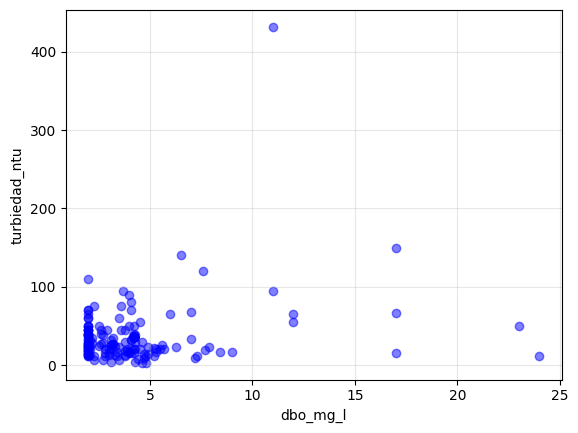

In [14]:
# graficar variable observada y la variable respuesta
plt.scatter(x, y, alpha=0.5, color='b', label='Datos')
plt.xlabel("dbo_mg_l")
plt.ylabel("turbiedad_ntu")
plt.grid(True, alpha=0.3)
plt.show()

## Preparar las variables

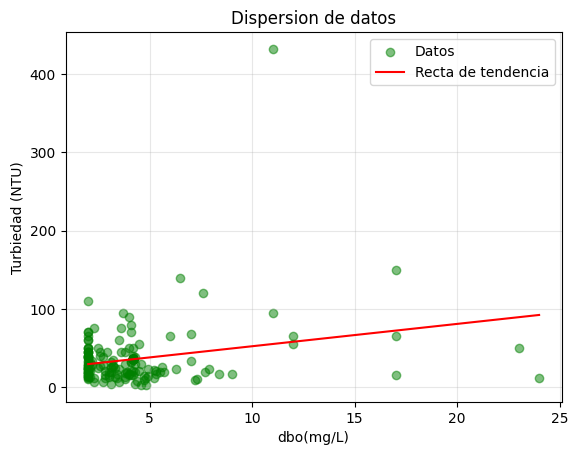

In [15]:
#Reshape recontruye el dataframe a 1 columna para que sklearn pueda trabajar
# usar nombres diferentes en las variables(X, Y) para no sobrescribir los DataFrames originales (x, y)
X = x.values.reshape(-1, 1)
Y = y.values

# se entrenan los datos con el modelo de regresion lineal para obtener la recta de tendencia
modelo = LinearRegression()
modelo.fit(X, Y)

#valores para la recta
x_linea = np.linspace(X.min(), X.max(), 50).reshape(-1, 1)
y_linea = modelo.predict(x_linea)


#Graficar recta de tendencia
plt.scatter(X, Y, color="green", alpha=0.5, label="Datos")
plt.plot(x_linea, y_linea, color="red", label="Recta de tendencia")


plt.xlabel("dbo(mg/L)")
plt.ylabel("Turbiedad (NTU)")
plt.title("Dispersion de datos")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Separar datos para entrenar

In [16]:
# usar train_test_split con los DataFrames originales (x, y), no con los arrays (X, Y),
# si no tira error y x_test sigue siendo un DataFrame y se puede usar .head()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)
x_test.head()

,dbo_mg_l
42,2.00
23,3.50
45,2.00
48,2.00
13,4.21


In [17]:
#dimensiones de los conjuntos de entrenamiento 80%
# "x" es dbo y "y" es turbiedad
print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

#datos para prueba 20%
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (135, 1)
y_train shape: (135, 1)
X_test shape: (34, 1)
y_test shape: (34, 1)


### Entrenar el modelo

In [18]:
#Se crea modelo de regresion lineal
modelo_nuevo = LinearRegression()

#este modelo se entrena con los datos Train
modelo_nuevo.fit(x_train, y_train)

LinearRegression()

In [19]:
# se crea la variable prediccion para guardar los valores predichos
# entonces desde modelo nuevo se llama a predict y se le pasa x_test
# con prediccion se busca predecir la turbiedad a partir de los valores de DBO
prediccion = modelo_nuevo.predict(x_test)

# se usa np.array para convertir la prediccion en un array de tipo float
prediccion= np.array(prediccion, dtype=float)
prediccion

array([[31.49220883],
       [34.84510839],
       [31.49220883],
       [31.49220883],
       [36.43214752],
       [31.9392621 ],
       [34.84510839],
       [33.95100184],
       [36.18626822],
       [31.49220883],
       [36.18626822],
       [31.49220883],
       [36.43214752],
       [36.43214752],
       [44.23322718],
       [32.60984201],
       [34.62158175],
       [31.49220883],
       [36.63332149],
       [36.63332149],
       [37.08037477],
       [31.49220883],
       [31.71573546],
       [35.96274158],
       [38.86858787],
       [36.40979486],
       [31.49220883],
       [37.52742804],
       [53.8448726 ],
       [36.18626822],
       [31.49220883],
       [65.02120448],
       [33.28042193],
       [53.8448726 ]])

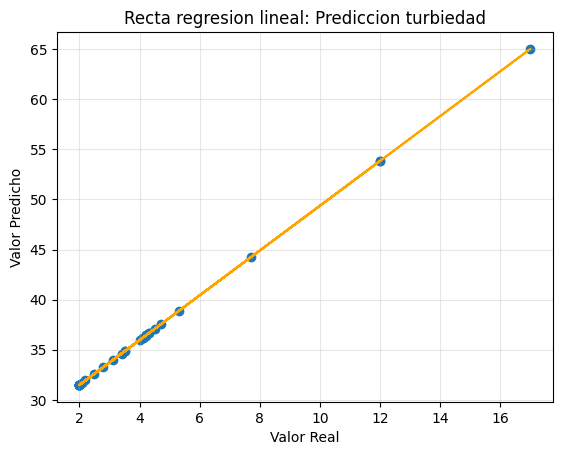

In [20]:
#graficar la recta de regresion del modelo predictivo
# recordar que "x" es dbo y "y" es turbiedad
#se uso values para convertir esto para que sklearn pueda trabajar con los datos
X_test_array = x_test.values

# x_test pertece al conjunto de prueba de la variable dbo
plt.scatter(X_test_array, prediccion)
plt.plot(X_test_array, prediccion, "orange")

plt.xlabel("Valor Real")
plt.ylabel("Valor Predicho")
plt.title("Recta regresion lineal: Prediccion turbiedad")
plt.grid(True, alpha=0.3)
plt.show()


### Ver valores reales y los valores predichos

In [21]:
#comparar en una tabla los valores reales y los valores predichos
y_test = np.array(y_test, dtype=float)

# flatten() es para convertir el array de 2 dimensiones a 1 dimension
#se crea un DataFrame con los valores reales y los valores predichos
#redondear los valores predichos a 2 decimales
prediccion_mostrar = np.round(prediccion, 2)
df_new = pd.DataFrame({"Valor real": y_test.flatten(), "Prediccion": prediccion_mostrar.flatten()})
#mostrar los primeros 10 valores reales y predichos
df_new.head(10)


,Valor real,Prediccion
0,45.00,31.49
1,23.00,34.85
2,50.00,31.49
3,50.00,31.49
4,35.78,36.43
5,28.00,31.94
6,6.00,34.85
7,26.00,33.95
8,32.00,36.19
9,50.00,31.49


### Metricas

In [22]:
Valor_real = y_test.flatten()
Valor_predicho = prediccion.flatten()

# Calcular metricas
mae = mean_absolute_error(Valor_real, Valor_predicho)
mse = mean_squared_error(Valor_real, Valor_predicho)

#con np.sqrt se calcula la raiz cuadrada del mse para obtener el rmse
#es lo mismo que rmse=mse**(1/2.0)
rmse = np.sqrt(mse)
r2 = r2_score(Valor_real, Valor_predicho)

# mostrar las metricas que se obtuvieron
print("Mean Absolute Error (MAE):%.2f" % mae)
print("Mean Squared Error (MSE):%.2f" % mse)
print("Root Mean Squared Error (RMSE):%.2f" % rmse)
print("Variance Score: %.2f" % r2)

Mean Absolute Error (MAE):14.01
Mean Squared Error (MSE):407.03
Root Mean Squared Error (RMSE):20.18
Variance Score: 0.33


## Analizar resultados
El Modelo no es bueno para predecir la turbiedad apartir de la demanda bioquimica de oxigeno en el agua. No se logra ajustar bien a los datos.
-  El puntaje de varianza es bajo no llega a 1, tienen una relacion muy debil, algo a mejorar podria ser sumar mas variables.
